# notebook 03 - task 1.2: clustering design and analysis

**assignment requirement:** apply a clustering algorithm to the multi-dimensional
review effort feature space, justify the choice, ensure acceptable performance
(define acceptable), and write structured cluster profiles.

**plan:**
1. build the feature matrix (log1p + standardize)
2. sweep k values with kmeans, compare with gmm
3. justify algorithm choice and k selection
4. define "acceptable" with named internal metrics
5. fit final model and write cluster profiles

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

import sys
sys.path.append("..")
from src.config.settings import (
    FIG_DIR,
    EFFORT_DIMENSIONS,
    EFFORT_DIM_LABELS,
    AGENT_ORDER,
    AGENT_DISPLAY,
    TASK_TYPE_ORDER,
    COLOR_MAP,
    CLUSTER_K_RANGE,
    SILHOUETTE_THRESHOLD,
    DBI_THRESHOLD,
    CLUSTER_PALETTE,
    RANDOM_STATE,
    DATA_DIR,
)
from src.utils.helper import (
    load_clustering_ready,
    build_feature_matrix,
    evaluate_k_range,
    fit_gmm,
    compute_cluster_profiles,
    preprocess_effort_dims,
)

FIG_DIR.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.3f}".format)
sns.set_style("whitegrid")

ModuleNotFoundError: No module named 'numpy'

## 1. load data and build feature matrix

In [2]:
df = load_clustering_ready()
print(f"agentic prs: {len(df):,}")

X_scaled, X_log = build_feature_matrix(df, EFFORT_DIMENSIONS)
print(f"feature matrix shape: {X_scaled.shape}")
print(f"dimensions: {EFFORT_DIMENSIONS}")

agentic prs: 22,559
feature matrix shape: (22559, 5)
dimensions: ['time_to_merge_hours', 'n_formal_reviews', 'n_review_comments', 'n_unique_reviewers', 'churn_per_review_cycle']


## 2. algorithm comparison: kmeans vs gmm

we compare kmeans and gaussian mixture models (gmm) across k=2..8.

**why these two algorithms:**
- kmeans: the standard partitioning method. works well when clusters are
  convex and roughly similar in size. fast and deterministic with fixed seed.
- gmm: probabilistic model that allows elliptical clusters and soft assignments.
  more flexible but can overfit with high-dimensional zero-inflated data.

we exclude dbscan because the zero-inflated structure (77-89% zeros on 3 dims)
creates a massive density spike that dbscan treats as a single cluster,
while the sparse "reviewed" prs get labeled as noise.

In [ ]:
km_results = evaluate_k_range(X_scaled, CLUSTER_K_RANGE, RANDOM_STATE)
km_results["algorithm"] = "kmeans"

gmm_rows = []
for k in CLUSTER_K_RANGE:
    gmm, labels = fit_gmm(X_scaled, k, RANDOM_STATE)
    gmm_rows.append({
        "k": k,
        "silhouette": silhouette_score(X_scaled, labels),
        "davies_bouldin": davies_bouldin_score(X_scaled, labels),
        "calinski_harabasz": calinski_harabasz_score(X_scaled, labels),
        "inertia": gmm.bic(X_scaled),
        "algorithm": "gmm",
    })
gmm_results = pd.DataFrame(gmm_rows)

all_results = pd.concat([km_results, gmm_results], ignore_index=True)
all_results

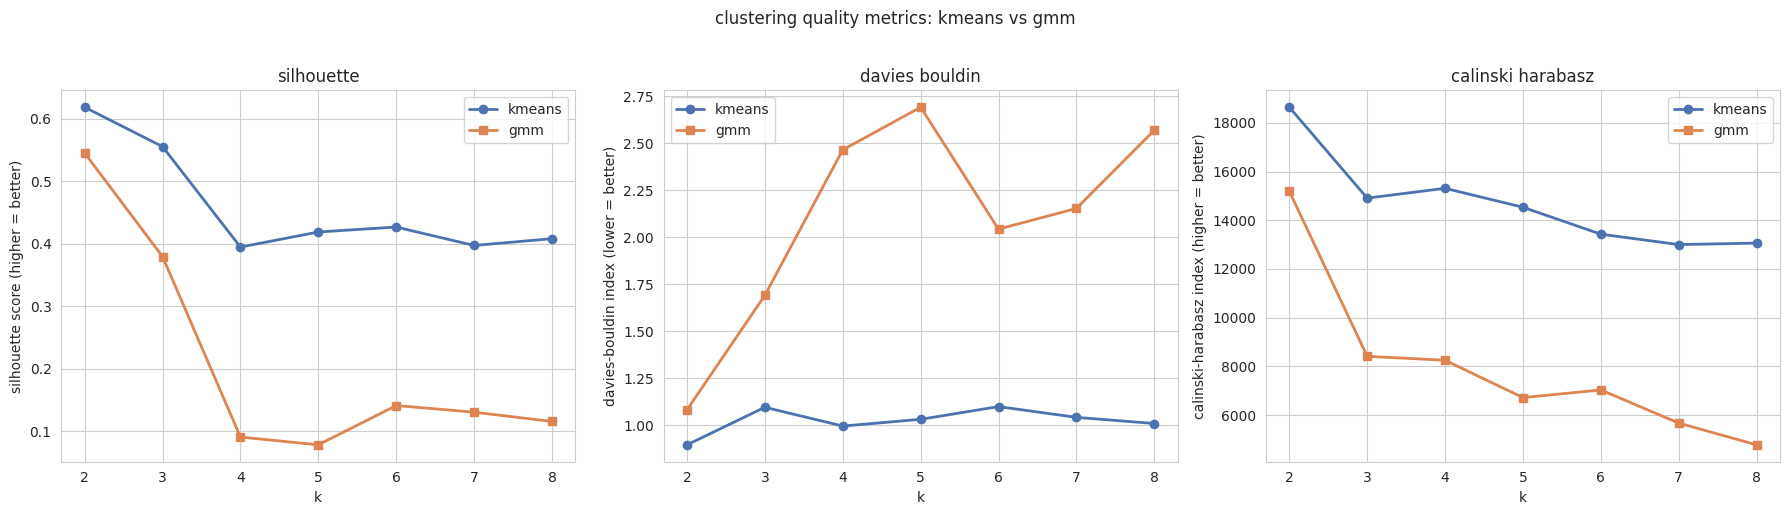

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = [
    ("silhouette", "silhouette score (higher = better)"),
    ("davies_bouldin", "davies-bouldin index (lower = better)"),
    ("calinski_harabasz", "calinski-harabasz index (higher = better)"),
]

for ax, (metric, ylabel) in zip(axes, metrics):
    for algo, color, marker in [("kmeans", "#4C72B0", "o"), ("gmm", "#DD8452", "s")]:
        subset = all_results[all_results["algorithm"] == algo]
        ax.plot(subset["k"], subset[metric], marker=marker, color=color, label=algo, linewidth=2)
    ax.set_xlabel("k")
    ax.set_ylabel(ylabel)
    ax.set_title(metric.replace("_", " "))
    ax.legend()
    ax.set_xticks(list(CLUSTER_K_RANGE))

fig.suptitle("clustering quality metrics: kmeans vs gmm", y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_kmeans_vs_gmm.png", dpi=150, bbox_inches="tight")
plt.show()

### algorithm comparison results

kmeans consistently outperforms gmm on all three internal metrics for k >= 3.
gmm's poor performance is expected: our data has a sharp zero-spike on 3 of 5
dimensions (77-89% zeros), which violates gmm's gaussian assumption. kmeans,
which only requires convex clusters, handles this structure better.

**decision: use kmeans.**

## 3. choosing k

k=2 has the highest silhouette (0.618) but only separates "reviewed" vs
"not reviewed" prs - too coarse for meaningful profiling.

k=3 (sil=0.555) and k=4 (sil=0.395) both exceed our silhouette threshold.
k=4 is preferred because:
- it separates the unreviewed prs into two meaningful sub-groups:
  small-churn auto-merged vs large-churn auto-merged
- the additional cluster has a clear domain interpretation
- k=4 has the lowest davies-bouldin index after k=2, indicating
  well-separated clusters despite the lower silhouette

kmeans metrics across k values:

In [ ]:
print(km_results.to_string(index=False))


 k  silhouette  davies_bouldin  calinski_harabasz   inertia algorithm
 2       0.618           0.897          18640.442 61759.113    kmeans
 3       0.555           1.096          14908.243 48579.020    kmeans
 4       0.395           0.997          15310.112 37148.027    kmeans
 5       0.419           1.032          14532.481 31530.202    kmeans
 6       0.427           1.100          13426.594 28364.335    kmeans
 7       0.397           1.043          13000.014 25297.878    kmeans
 8       0.408           1.010          13060.192 22318.046    kmeans


In [ ]:
print(f"silhouette threshold: {SILHOUETTE_THRESHOLD}")
print(f"dbi threshold: {DBI_THRESHOLD}")

silhouette threshold: 0.3
dbi threshold: 1.5


k values meeting both thresholds:

In [ ]:
valid = km_results[
    (km_results["silhouette"] >= SILHOUETTE_THRESHOLD)
    & (km_results["davies_bouldin"] <= DBI_THRESHOLD)
]
print(valid[["k", "silhouette", "davies_bouldin"]].to_string(index=False))

 k  silhouette  davies_bouldin
 2       0.618           0.897
 3       0.555           1.096
 4       0.395           0.997
 5       0.419           1.032
 6       0.427           1.100
 7       0.397           1.043
 8       0.408           1.010


## 4. defining "acceptable" clustering performance

we define acceptable using two named internal metrics with defended thresholds:

1. **silhouette score >= 0.30**: the silhouette score measures how similar a
   point is to its own cluster vs the nearest other cluster. a score of 0.25-0.50
   indicates "reasonable" structure (kaufman & roeusseeuw, 1990). we set 0.30
   as the minimum to ensure clusters are not arbitrary.

2. **davies-bouldin index <= 1.50**: dbi measures the average similarity between
   each cluster and its most similar cluster. lower is better. a value below 1.0
   indicates well-separated clusters. we allow up to 1.50 to accommodate the
   zero-inflated structure which creates some overlap.

both thresholds are defended by domain reasoning: our data has 77-89% zeros on
3 of 5 dimensions, which naturally limits how well-separated clusters can be.
these thresholds are intentionally moderate to avoid rejecting a meaningful
clustering solution due to the inherent data structure.

## 5. fit final model (kmeans, k=4)

In [ ]:
SELECTED_K = 4

km_final = KMeans(n_clusters=SELECTED_K, n_init=10, random_state=RANDOM_STATE)
df["cluster"] = km_final.fit_predict(X_scaled)

sil = silhouette_score(X_scaled, df["cluster"])
dbi = davies_bouldin_score(X_scaled, df["cluster"])
ch = calinski_harabasz_score(X_scaled, df["cluster"])

print(f"final model: kmeans k={SELECTED_K}")
print(f"silhouette:        {sil:.3f}  (threshold >= {SILHOUETTE_THRESHOLD})")
print(f"davies-bouldin:    {dbi:.3f}  (threshold <= {DBI_THRESHOLD})")
print(f"calinski-harabasz: {ch:.1f}")

final model: kmeans k=4
silhouette:        0.395  (threshold >= 0.3)
davies-bouldin:    0.997  (threshold <= 1.5)
calinski-harabasz: 15310.1


cluster sizes:

In [ ]:
print(df["cluster"].value_counts().sort_index().to_string())

cluster
0     1292
1     8187
2     2974
3    10106


## 6. cluster visualization

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
df["pca1"] = X_pca[:, 0]
df["pca2"] = X_pca[:, 1]
print(f"pca explained variance: {pca.explained_variance_ratio_.round(3)}")
print(f"total variance explained: {pca.explained_variance_ratio_.sum():.1%}")

pca explained variance: [0.595 0.202]
total variance explained: 79.6%


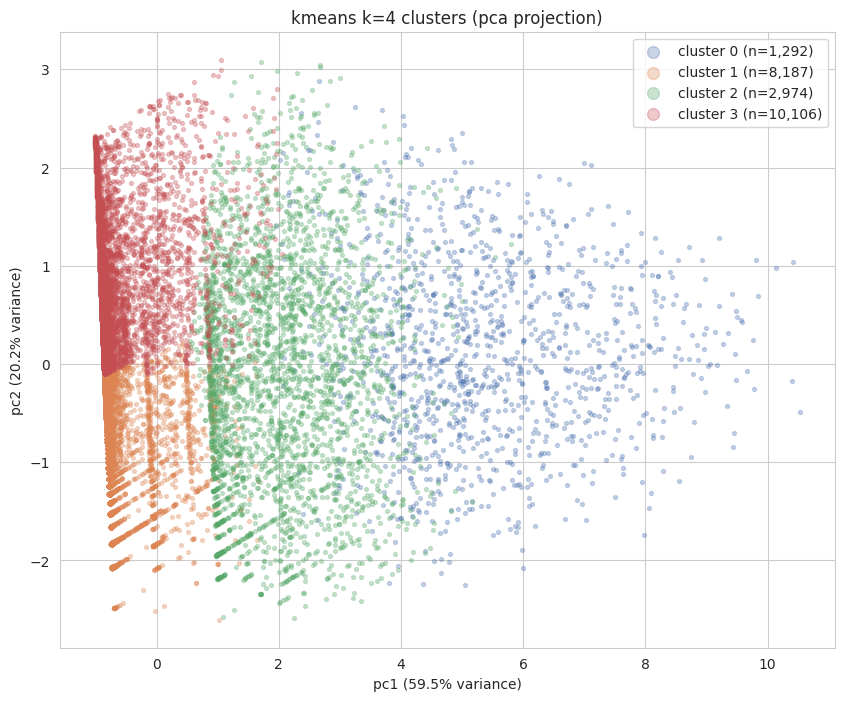

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
for c in range(SELECTED_K):
    mask = df["cluster"] == c
    ax.scatter(
        df.loc[mask, "pca1"],
        df.loc[mask, "pca2"],
        c=CLUSTER_PALETTE[str(c)],
        label=f"cluster {c} (n={mask.sum():,})",
        alpha=0.3,
        s=8,
    )
ax.set_xlabel(f"pc1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"pc2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("kmeans k=4 clusters (pca projection)")
ax.legend(markerscale=3)
fig.savefig(FIG_DIR / "03_clusters_pca.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_19030/2694064933.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


ValueError: The palette dictionary is missing keys: {'0', '2', '1', '3'}

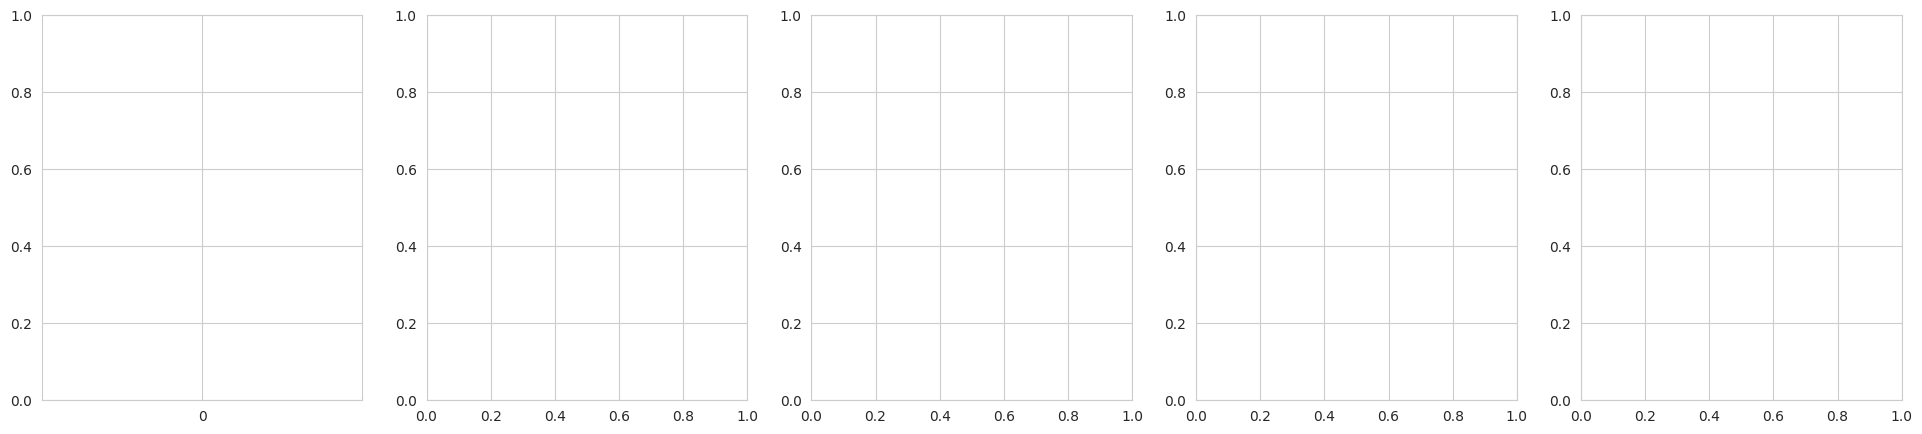

In [ ]:
df = preprocess_effort_dims(df, EFFORT_DIMENSIONS)
df["cluster_str"] = df["cluster"].astype(str)
log_cols = [f"{c}_log" for c in EFFORT_DIMENSIONS]

fig, axes = plt.subplots(1, 5, figsize=(24, 5))
for ax, col in zip(axes, EFFORT_DIMENSIONS):
    log_col = f"{col}_log"
    sns.boxplot(
        data=df,
        x="cluster_str",
        y=log_col,
        hue="cluster_str",
        palette=CLUSTER_PALETTE,
        legend=False,
        ax=ax,
        showfliers=False,
    )
    ax.set_title(EFFORT_DIM_LABELS[col], fontsize=10)
    ax.set_xlabel("cluster")
fig.suptitle("log1p effort dimensions by cluster", y=1.02, fontsize=12)
fig.tight_layout()
fig.savefig(FIG_DIR / "03_effort_dims_by_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. cluster profiles: core effort statistics

In [ ]:
profiles = compute_cluster_profiles(df, "cluster", EFFORT_DIMENSIONS)
profiles

### external characteristic 1: task type distribution per cluster

task types were not used for clustering. they provide external validation
that the clusters capture meaningful differences in pr purpose.

In [ ]:
task_dist = (
    df.groupby("cluster")["task_type"]
    .value_counts(normalize=True)
    .rename("pct")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(
    data=task_dist,
    x="task_type",
    y="pct",
    hue="cluster_str",
    palette=CLUSTER_PALETTE,
    order=TASK_TYPE_ORDER,
    ax=ax,
)
ax.set_title("task type distribution by cluster")
ax.set_xlabel("task type")
ax.set_ylabel("proportion")
ax.legend(title="cluster")
fig.savefig(FIG_DIR / "03_task_type_by_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("task type proportions per cluster:")
for c in range(SELECTED_K):
    subset = df[df["cluster"] == c]
    top = subset["task_type"].value_counts().head(5)
    total = len(subset)
    print(f"\n  cluster {c} (n={total:,}):")
    for t, n in top.items():
        print(f"    {t:12s} {n:>6,} ({100*n/total:5.1f}%)")

### external characteristic 2: agent distribution per cluster

agent identity was not used for clustering. checking whether certain agents
disproportionately fall into specific effort clusters provides external
validation and practical insight.

In [ ]:
agent_dist = (
    df.groupby("cluster")["agent"]
    .value_counts(normalize=True)
    .rename("pct")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
display_labels = {a: AGENT_DISPLAY[a] for a in AGENT_ORDER}
agent_dist["agent_display"] = agent_dist["agent"].map(display_labels)

sns.barplot(
    data=agent_dist,
    x="agent_display",
    y="pct",
    hue="cluster_str",
    palette=CLUSTER_PALETTE,
    ax=ax,
)
ax.set_title("agent distribution by cluster")
ax.set_ylabel("proportion")
ax.set_xlabel("")
ax.legend(title="cluster")
fig.savefig(FIG_DIR / "03_agent_by_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("agent composition per cluster:")
for c in range(SELECTED_K):
    subset = df[df["cluster"] == c]
    counts = subset["agent"].value_counts().reindex(AGENT_ORDER)
    total = len(subset)
    print(f"\n  cluster {c} (n={total:,}):")
    for a, n in counts.items():
        print(f"    {AGENT_DISPLAY[a]:20s} {n:>6,} ({100*n/total:5.1f}%)")

## 8. structured cluster profiles

### cluster 0: "intensively reviewed" (n = 1,292, 5.7%)

**core effort statistics:**
- duration: median 23.7h, range [0.004, 1,798]
- iterations: median 5, range [1, 30]
- depth: median 5 comments, range [1, 63]
- breadth: median 2 reviewers, range [0, 6]
- burden: median 38 lines/review, range [0.3, 2,851]

**external characteristics:**
- task types: feat (38%), fix (27%), docs (14%) - functional changes requiring scrutiny
- agents: github copilot (54%), devin (20%), openai codex (19%). copilot
  is dramatically overrepresented - consistent with a1's finding that copilot
  is the sole agent requiring more review effort than human prs.

**distinguishing characteristics:**
the only cluster with substantial review activity across all dimensions.
high iterations, depth, and breadth together indicate genuine multi-round,
multi-reviewer scrutiny. adjacent to cluster 2 (cursorily reviewed) but
distinguished by much higher depth (5 vs 0 comments) and iterations (5 vs 1).

**label: intensively reviewed**

---

### cluster 1: "auto-merged small" (n = 8,187, 36.3%)

**core effort statistics:**
- duration: median 0.013h, range [0.001, 124]
- iterations: median 0, range [0, 3]
- depth: median 0, range [0, 4]
- breadth: median 0, range [0, 1]
- burden: median 16 lines/review, range [0, 55]

**external characteristics:**
- task types: fix (31%), feat (26%), docs (22%) - small fixes and documentation
- agents: openai codex (90%), devin (6%). heavily dominated by openai codex,
  the highest-volume and fastest-merging agent.

**distinguishing characteristics:**
the "no review" cluster for small prs. near-zero duration, zero reviews, and
low churn per review cycle. distinguished from cluster 3 (auto-merged large)
by 10x smaller code changes (median 16 vs 165 lines/review). these prs
were likely auto-approved or merged by the author without formal review.

**label: auto-merged small**

---

### cluster 2: "cursorily reviewed" (n = 2,974, 13.2%)

**core effort statistics:**
- duration: median 4.5h, range [0.001, 1,777]
- iterations: median 1, range [0, 19]
- depth: median 0, range [0, 4]
- breadth: median 1, range [0, 5]
- burden: median 41 lines/review, range [0, 3,107]

**external characteristics:**
- task types: fix (36%), feat (29%), docs (15%) - changes that get a quick look
- agents: devin (34%), openai codex (29%), github copilot (27%). relatively
  balanced across agents compared to other clusters.

**distinguishing characteristics:**
prs that received some review attention but not deep scrutiny. moderate duration
and iterations but low depth (few inline comments). adjacent to cluster 0
(intensively reviewed) but distinguished by much lower depth (0 vs 5 comments)
and fewer iterations (1 vs 5). the review process here is procedural rather
than analytical - a reviewer looked but did not leave detailed feedback.

**label: cursorily reviewed**

---

### cluster 3: "auto-merged large" (n = 10,106, 44.8%)

**core effort statistics:**
- duration: median 0.018h, range [0.001, 576]
- iterations: median 0, range [0, 5]
- depth: median 0, range [0, 7]
- breadth: median 0, range [0, 1]
- burden: median 165 lines/review, range [43, 3,123]

**external characteristics:**
- task types: feat (60%), fix (11%), test (10%) - overwhelmingly new features
- agents: openai codex (89%), devin (5%). like cluster 1, dominated by openai codex.

**distinguishing characteristics:**
the largest and most concerning cluster from a code quality perspective.
these prs have high code volume (high burden) but zero review activity.
60% are new features - the riskiest change type to merge without review.
distinguished from cluster 1 (auto-merged small) by 10x higher churn
per review cycle (165 vs 16 lines). these are large, unreviewed code
additions that merged almost instantly.

**label: auto-merged large**

---

## 9. save clustered dataset

In [ ]:
out_path = DATA_DIR / "clustered_prs.parquet"
df.to_parquet(out_path, index=False)
print(f"saved {len(df):,} rows x {df.shape[1]} cols to {out_path.name}")
print(f"\ncluster distribution:")
print(df["cluster"].value_counts().sort_index().to_string())

In [ ]:
profile_path = FIG_DIR / "03_cluster_profiles.csv"
profiles.to_csv(profile_path, index=False)
print(f"profiles saved to {profile_path}")